In [10]:
import numpy as np 
import os 
import matplotlib.pyplot as plt
import pandas as pd
from cooltools.lib import plotting

from matplotlib.colors import LogNorm

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

In [11]:

def get_Ps_curve_sim(contact_map):
    '''Get the P(s) curve of a simulated monomer-resolution contact map.'''
    dist_arr = np.arange(0, contact_map.shape[0])  # array of distances to calculate P(s) for (in monomers)
    mean_contact_prob_arr = np.zeros(len(dist_arr))
    for i, dist in enumerate(dist_arr):
        contact_probs_along_diag = np.diag(contact_map, dist)
        mean_contact_prob_arr[i] = np.mean(contact_probs_along_diag)  # ignore nan's
    return dist_arr, mean_contact_prob_arr

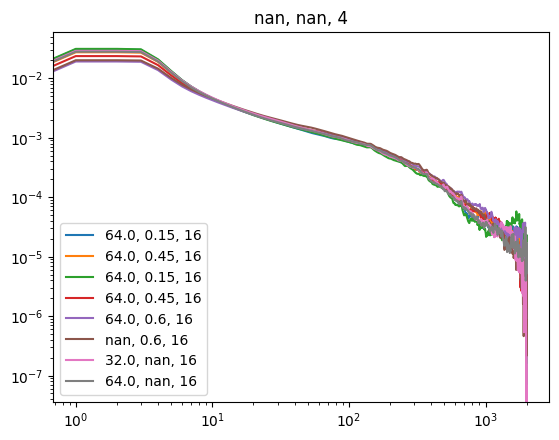

In [12]:
savedir = "/mnt/md1/varshini/Blood/sim_density_processed_balanced_wholeChrom/"
mapping = pd.read_csv(os.path.join(savedir, "mapping.tsv"), sep="\t")

for ind, row in mapping.iterrows():
    if row.loading_width == 16:
        cm_rescaled = np.load(os.path.join(savedir, f"{row.run_id}_{row.sim_id}_arr.npy"))
        x1, y1 = get_Ps_curve_sim(cm_rescaled)
        plt.loglog(x1, y1, label=f"{row.cohesins_per_mm}, {row.volume_density}, {row.loading_width}")
        #plt.xlim([10, 10e3])
        #plt.ylim([1e-4, 0.5])
        #y1d = np.gradient(np.log(x1[5:100]), np.log(y1[5:100]))
        #plt.semilogx(x1[5:100]*1000, y1d,label=f"{row.cohesins_per_mm}, {row.volume_density}, {row.loading_width}",
        #             linewidth=2)
plt.title(f"{row.cohesins_per_mm}, {row.volume_density}, {row.loading_width}")
plt.legend()
plt.show()
 

In [13]:
os.mkdir(savedir)

FileExistsError: [Errno 17] File exists: '/mnt/md1/varshini/Blood/sim_density_processed_balanced_wholeChrom/'

In [14]:
pad_width = 1000
region_size = 2000

In [15]:
def sinkhorn_knopp(cm, n_iterations=25):
    n = np.shape(cm)[0]
    cm_iter = cm.copy()

    D1 = np.ones(n)
    D2 = np.ones(n)

    for i in range(n_iterations):
        column_sums = cm_iter.sum(axis=0)
        row_sums = cm_iter.sum(axis=1)
        if (i % 2) == 0:
            D1 *= (1.0 / row_sums)
        else:
            D2 *= (1.0 / column_sums)

        dot_D2 = cm * D2
        cm_iter = D1[:, None] * dot_D2
    return cm_iter

In [16]:
cm_rescaled

array([[0.00000000e+00, 2.90273016e-02, 2.91458723e-02, ...,
        1.27788467e-05, 1.53887273e-05, 1.66753581e-05],
       [2.90273425e-02, 0.00000000e+00, 2.92340019e-02, ...,
        1.40992353e-05, 1.54352588e-05, 1.54391816e-05],
       [2.91459921e-02, 2.92340809e-02, 0.00000000e+00, ...,
        9.00891478e-06, 1.42068215e-05, 1.55022894e-05],
       ...,
       [1.27798925e-05, 1.41003693e-05, 9.00961506e-06, ...,
        0.00000000e+00, 2.49741770e-02, 2.49805240e-02],
       [1.53900383e-05, 1.54365521e-05, 1.42079734e-05, ...,
        2.49742606e-02, 0.00000000e+00, 2.50687568e-02],
       [1.66768391e-05, 1.54405311e-05, 1.55036026e-05, ...,
        2.49806981e-02, 2.50688476e-02, 0.00000000e+00]])

In [17]:
plt.figure(figsize=(5, 5))
cm_rescaled = cm_balanced[pad_width:(pad_width+region_size), pad_width:(pad_width+region_size)]
plt.imshow(cm_rescaled[150:750, 150:750], cmap='fall',vmax=0.005);
plt.colorbar(label='contacts per repeat per block');
plt.title(f"{row.cohesins_per_mm}, {row.volume_density}, {row.loading_width}")

NameError: name 'cm_balanced' is not defined

<Figure size 500x500 with 0 Axes>

In [18]:
def anti_insulation_score(snip, verbose=True, nan_thresh=1):
    n = snip.shape[0]
    if n == 0 or snip.shape[0] != snip.shape[1]:
        return np.nan

    if (np.isnan(snip).sum() / snip.size) > nan_thresh:
        return np.nan

    triu = np.triu(snip)
    mid = n // 2 # adjust for the 2 pix excl in the snipper

    # Top square: rows 0:mid, cols mid:n
    top_square = triu[2:mid, mid:-2]
    top_left_triangle = triu[2:mid, 2:mid]
    bottom_right_triangle = triu[mid:-2, mid:-2]

    numerator = np.nansum(top_square)
    denominator = np.nansum(top_left_triangle) + np.nansum(bottom_right_triangle)

    if verbose:
        plt_regions = snip.copy()
        plt_regions[2:mid, mid:-2] = 3
        plt_regions[2:mid, 2:mid] = 1
        plt_regions[mid:-2, mid:-2] = 2

        top_square_counts = np.count_nonzero(~np.isnan(top_square))
        bottom_right_counts = np.count_nonzero(~np.isnan(bottom_right_triangle))
        top_left_counts = np.count_nonzero(~np.isnan(top_left_triangle))
        print(top_square_counts, bottom_right_counts, top_left_counts)
        f, ax = plt.subplots()
        ax.matshow(snip)
        ax.matshow(plt_regions, alpha=0.2)

        ax.axvline(mid, color='red', linestyle='dotted', linewidth=2)
        ax.axhline(mid, color='red', linestyle='dotted', linewidth=2)
        ax.axvline(2, color='red', linestyle='dotted', linewidth=2)
        ax.axhline(n-2, color='red', linestyle='dotted', linewidth=2)
        plt.show()

    if denominator == 0:
        return np.nan

    return numerator / denominator

In [19]:
def kth_diag_indices(a, k):
    rows, cols = np.diag_indices_from(a)
    if k < 0:
        return rows[-k:], cols[:k]
    elif k > 0:
        return rows[:-k], cols[k:]
    else:
        return rows, cols

In [201]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v2/sim_contact_maps_fountain/"
mapdir = "/mnt/md1/varshini/Blood/sim_compaction_fountain_processed_Bal/"
mapping = pd.read_csv(os.path.join(mapdir, "mapping.tsv"), sep="\t")

for ind, row in mapping.iterrows():
    
    if row.volume_density == 0.3 and row.loading_width==8:
        print(row)
        cm_rescaled = np.load(os.path.join(mapdir, f"{row.run_id}_{row.sim_id}_arr.npy"))

        x1, y1 = get_Ps_curve_sim(cm_rescaled)

        n = cm_rescaled.shape[0]
        cm_oe = np.zeros(np.shape(cm_rescaled))
        cm_oe = cm_rescaled.copy()
        for k, exp in enumerate(y1):
            inds = kth_diag_indices(cm_oe, k)
            cm_oe[inds] /= exp

        cm_sub_og = cm_oe[150:750, 150:750]

run_id                                                         run_003
sim_id                                                          sim_00
original_path        /mnt/md1/varshini/Blood/sim_data_compaction_fo...
result_file                                   run_003_sim_00_loops.tsv
parameters_file                          run_003_sim_00_parameters.txt
processivity                                                       300
separations                                                        240
ctcf_boost_factor                                                    4
llp                                                                  2
h                                                                  0.4
loading_width                                                        8
cohesins_per_mm                                                    128
volume_density                                                     0.3
vel_steps                                                 (0.0025, 50)
Name: 

/tmp/ipykernel_77979/198374986.py:18: RuntimeWarning: invalid value encountered in divide
  cm_oe[inds] /= exp


In [202]:
def plot_ortho_stripe(snip, ax, c="#CC3311"):
    n = snip.shape[0]
    mid = n // 2
    np.isnan(arr)
    # compute valid range lengths
    steps_up = mid + 1
    steps_right = n - mid
    L = min(steps_up, steps_right)

    # equal-length indices for the 45 anti-diagonal (upper half)
    rows = np.arange(mid, mid - L, -1)
    cols = np.arange(mid, mid + L)
    #plt.matshow(np.zeros([n,n]))
    #plt.scatter(rows[:4], cols[:4], cmap='Blues')
    ortho_stripe = snip[rows, cols]
    max_ortho_ind = np.nanargmax(ortho_stripe)
    ax.plot(ortho_stripe[:100], color=c)
    print(max_ortho_ind)
    
    pass

In [209]:
def plot_x_diags(mat, ax, n=[0, 20], c="#CC3311"):
    mat[np.isnan(mat)] = 0
    diags_all = []
    for offset in range(n[0], n[1]):
        diag_vals = np.diagonal(mat, offset=offset)
        diag_vals = np.pad(diag_vals, (int(np.floor((len(np.diagonal(mat, 0))-len(diag_vals))/2)), 
                           int(np.ceil((len(np.diagonal(mat, 0))-len(diag_vals))/2))))
        diags_all.append(diag_vals)
   # print(diags_all)
    diags_avg = np.vstack(diags_all).mean(axis=0)
    spl = make_smoothing_spline(np.arange(0, len(diags_avg)), diags_avg, lam=1)
    ax.scatter(np.linspace(0, len(diags_avg), len(diags_avg)), diags_avg, label=f'diagonal {offset}', s=2, color=c)
    ax.plot(np.arange(0, len(diags_avg)), spl(np.arange(0, len(diags_avg))), color=c)

def plot_x_diags_two(mat1,mat2, ax, n=[0, 20], c="#CC3311"):
    mat1[np.isnan(mat1)] = 0
    mat2[np.isnan(mat2)] = 0
    diags_all = []
    for offset in range(n[0], n[1]):
        diag_vals1 = np.diagonal(mat1, offset=offset)
        diag_vals1 = np.pad(diag_vals1, (int(np.floor((len(np.diagonal(mat1, 0))-len(diag_vals1))/2)), 
                           int(np.ceil((len(np.diagonal(mat1, 0))-len(diag_vals1))/2))))
        
        diag_vals2 = np.diagonal(mat2, offset=offset)
        diag_vals2 = np.pad(diag_vals2, (int(np.floor((len(np.diagonal(mat2, 0))-len(diag_vals2))/2)), 
                           int(np.ceil((len(np.diagonal(mat2, 0))-len(diag_vals2))/2))))
        diags_all.append(diag_vals1 - diag_vals2)
        #ax.scatter(np.linspace(0, len(diag_vals2), len(diag_vals2)), diag_vals1 - diag_vals2, 
        #           label=f'diagonal {offset}', s=2, color=c)
   # print(diags_all)
    diags_avg = np.vstack(diags_all).mean(axis=0)
    #spl = make_smoothing_spline(np.arange(0, len(diags_avg)), diags_avg, lam=1)
    ax.scatter(np.linspace(0, len(diags_avg), len(diags_avg)), diags_avg, label=f'diagonal {offset}', s=2, color=c)
    #ax.plot(np.arange(0, len(diags_avg)), spl(np.arange(0, len(diags_avg))), color=c)
      

/tmp/ipykernel_77979/629939749.py:20: RuntimeWarning: invalid value encountered in divide
  cm_oe[inds] /= exp


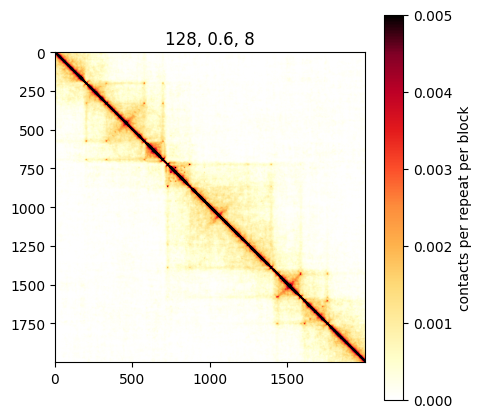

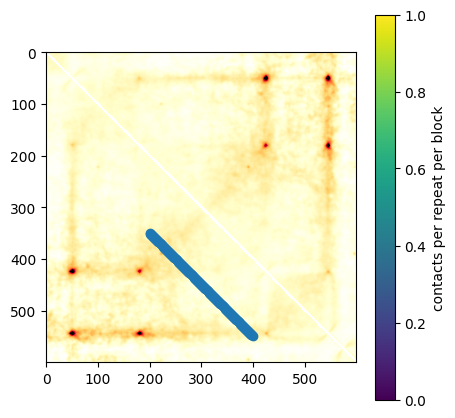

/tmp/ipykernel_77979/629939749.py:40: RuntimeWarning: divide by zero encountered in log2
  diff_cm = np.log2(cm_sub) - np.log2(cm_sub_og)


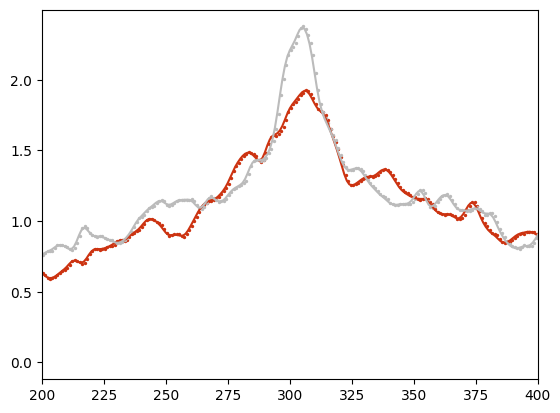

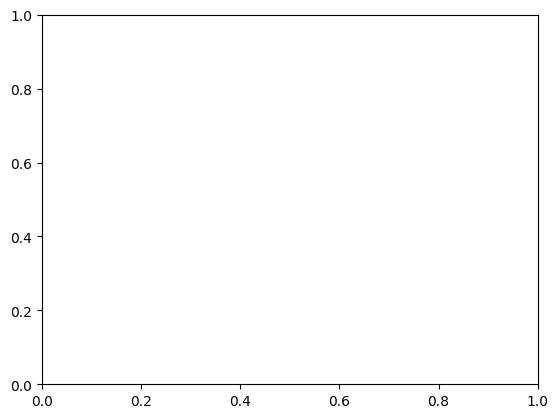

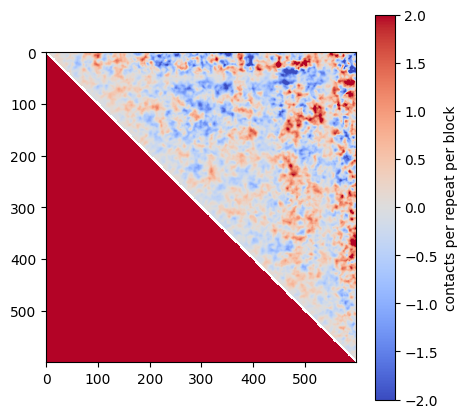

/tmp/ipykernel_77979/629939749.py:23: RuntimeWarning: invalid value encountered in divide
  cm_oe[inds] /= exp


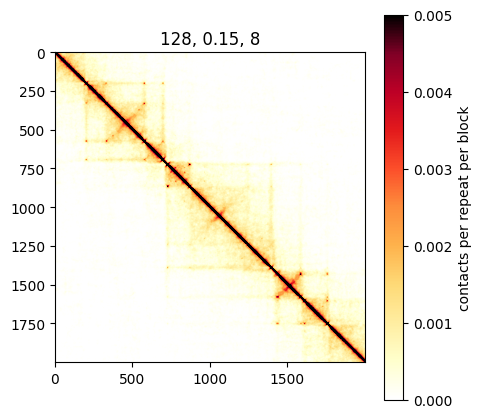

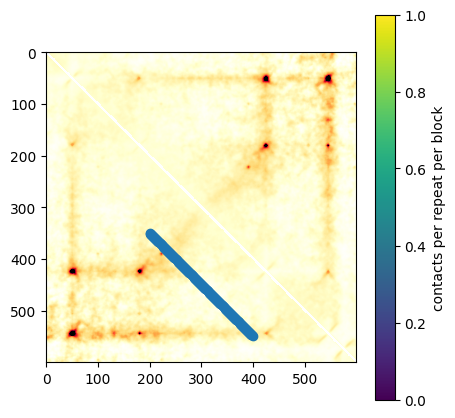

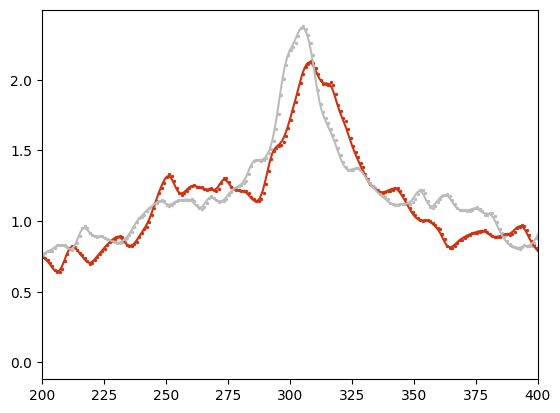

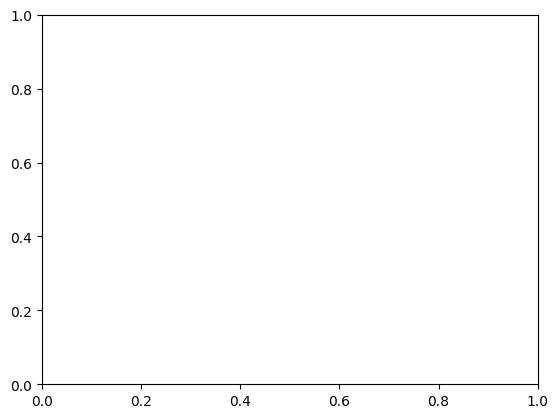

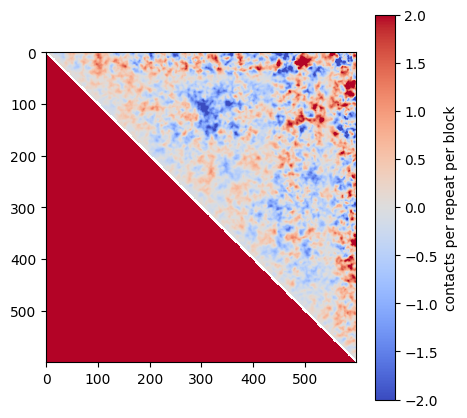

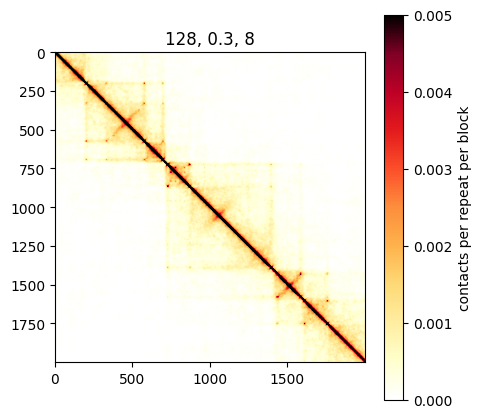

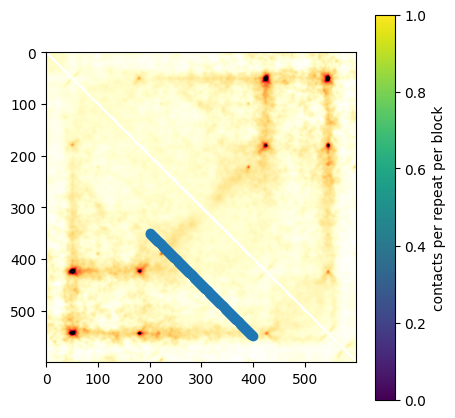

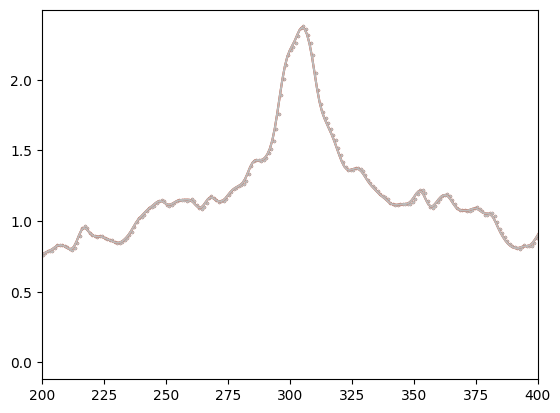

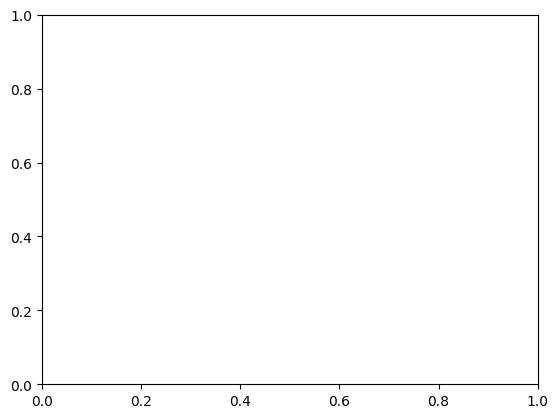

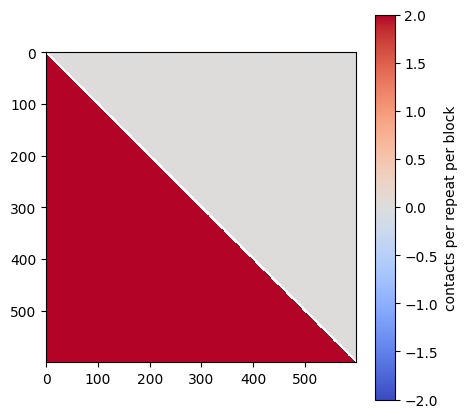

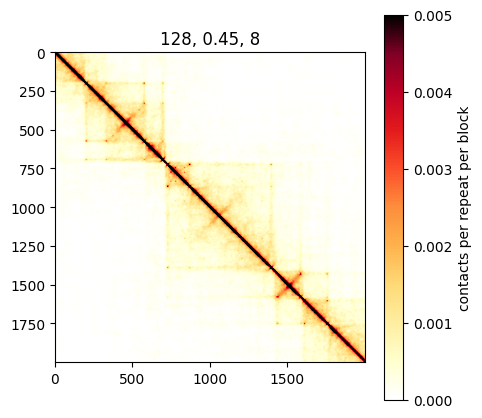

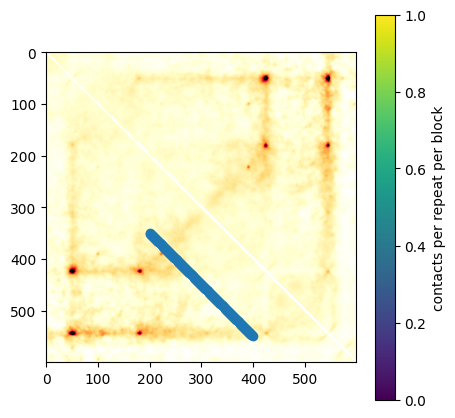

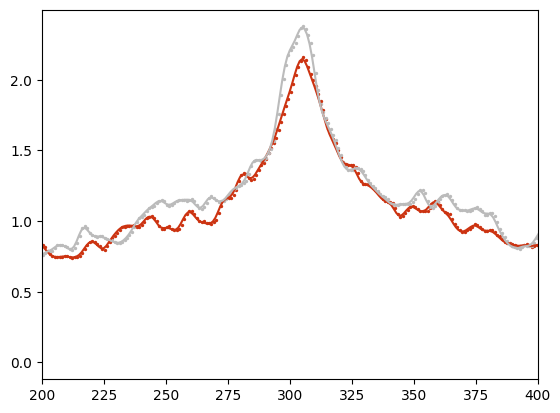

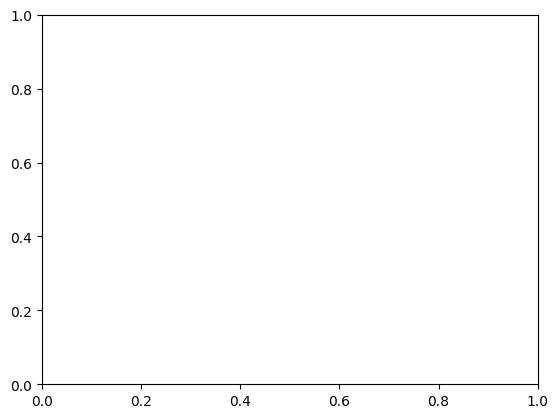

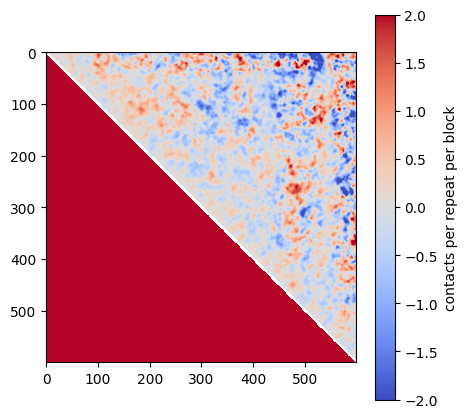

In [218]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v4/sim_contact_maps_fountain/"
mapdir = "/mnt/md1/varshini/Blood/sim_compaction_fountain_processed_Bal/"
mapping = pd.read_csv(os.path.join(mapdir, "mapping.tsv"), sep="\t")
if not os.path.exists(savedir):
    os.mkdir(savedir)
  

            
for ind, row in mapping.iterrows():
    if row.loading_width == 8:
        cm_rescaled = np.load(os.path.join(mapdir, f"{row.run_id}_{row.sim_id}_arr.npy"))

        x1, y1 = get_Ps_curve_sim(cm_rescaled)

        n = cm_rescaled.shape[0]
        cm_oe = np.zeros(np.shape(cm_rescaled))
        cm_oe = cm_rescaled.copy()
        for k, exp in enumerate(y1):
            inds = kth_diag_indices(cm_oe, k)
            cm_oe[inds] /= exp
        for k, exp in enumerate(y1):
            inds = kth_diag_indices(cm_oe, -k)
            cm_oe[inds] /= exp
        plt.figure(figsize=(5, 5))
        plt.imshow(cm_rescaled, cmap='fall', vmax=0.005);
        plt.colorbar(label='contacts per repeat per block');
        plt.title(f"{row.cohesins_per_mm}, {row.volume_density}, {row.loading_width}")
            #plt.savefig(os.path.join(savedir, f"n{row.cohesins_per_mm}_d{row.volume_density}_w{row.loading_width}_full.svg"))

        plt.show()

        cm_sub = cm_oe[150:750, 150:750]
        plt.figure(figsize=(5, 5))
        plt.imshow(cm_sub, cmap='fall', vmax=10);
        plt.scatter(kth_diag_indices(cm_sub, 50)[0], kth_diag_indices(cm_sub, 50)[1])
        plt.colorbar(label='contacts per repeat per block');
        #plt.savefig(os.path.join(savedir, f"n{row.cohesins_per_mm}_d{row.volume_density}_w{row.loading_width}.svg"))
        plt.show()

        diff_cm = np.log2(cm_sub) - np.log2(cm_sub_og)
        f, ax = plt.subplots()
    #     plot_ortho_stripe(cm_sub,ax, c="#cc3311")
    #     plot_ortho_stripe(cm_sub_og,ax,c="#BBBBBB")
        plot_x_diags(cm_sub, ax, n=[50,150], c="#cc3311")
        plot_x_diags(cm_sub_og, ax,n=[50,150], c="#BBBBBB")
        plt.xlim([200,400])
        plt.savefig(os.path.join(savedir, f"n{row.cohesins_per_mm}_d{row.volume_density}_w{row.loading_width}_avg_diags.svg"))

        plt.show()
        
        
        f, ax = plt.subplots()
    #     plot_ortho_stripe(cm_sub,ax, c="#cc3311")
    #     plot_ortho_stripe(cm_sub_og,ax,c="#BBBBBB")
        #plot_x_diags_two(cm_sub_og, cm_sub, ax, n=[0,500], c="#cc3311")
        
        plt.show()

        plt.figure(figsize=(5, 5))
        plt.imshow(diff_cm, cmap='coolwarm', vmin=-2, vmax=2);
        plt.colorbar(label='contacts per repeat per block');
            #plt.savefig(os.path.join(savedir, f"n{row.cohesins_per_mm}_d{row.volume_density}_w{row.loading_width}.svg"))
        plt.show()

            #print(tscore)

        #f='n64_h0.4_llp2_w16_dens0.6'
        #cm_rescaled = np.load(os.path.join(savedir, f"{f}.npy"))
            # show rescaled contact map

In [211]:
from scipy.interpolate import make_smoothing_spline


['sim_proc300_sep240_', 'n64_h0.4_llp2_w16_dens0.6']


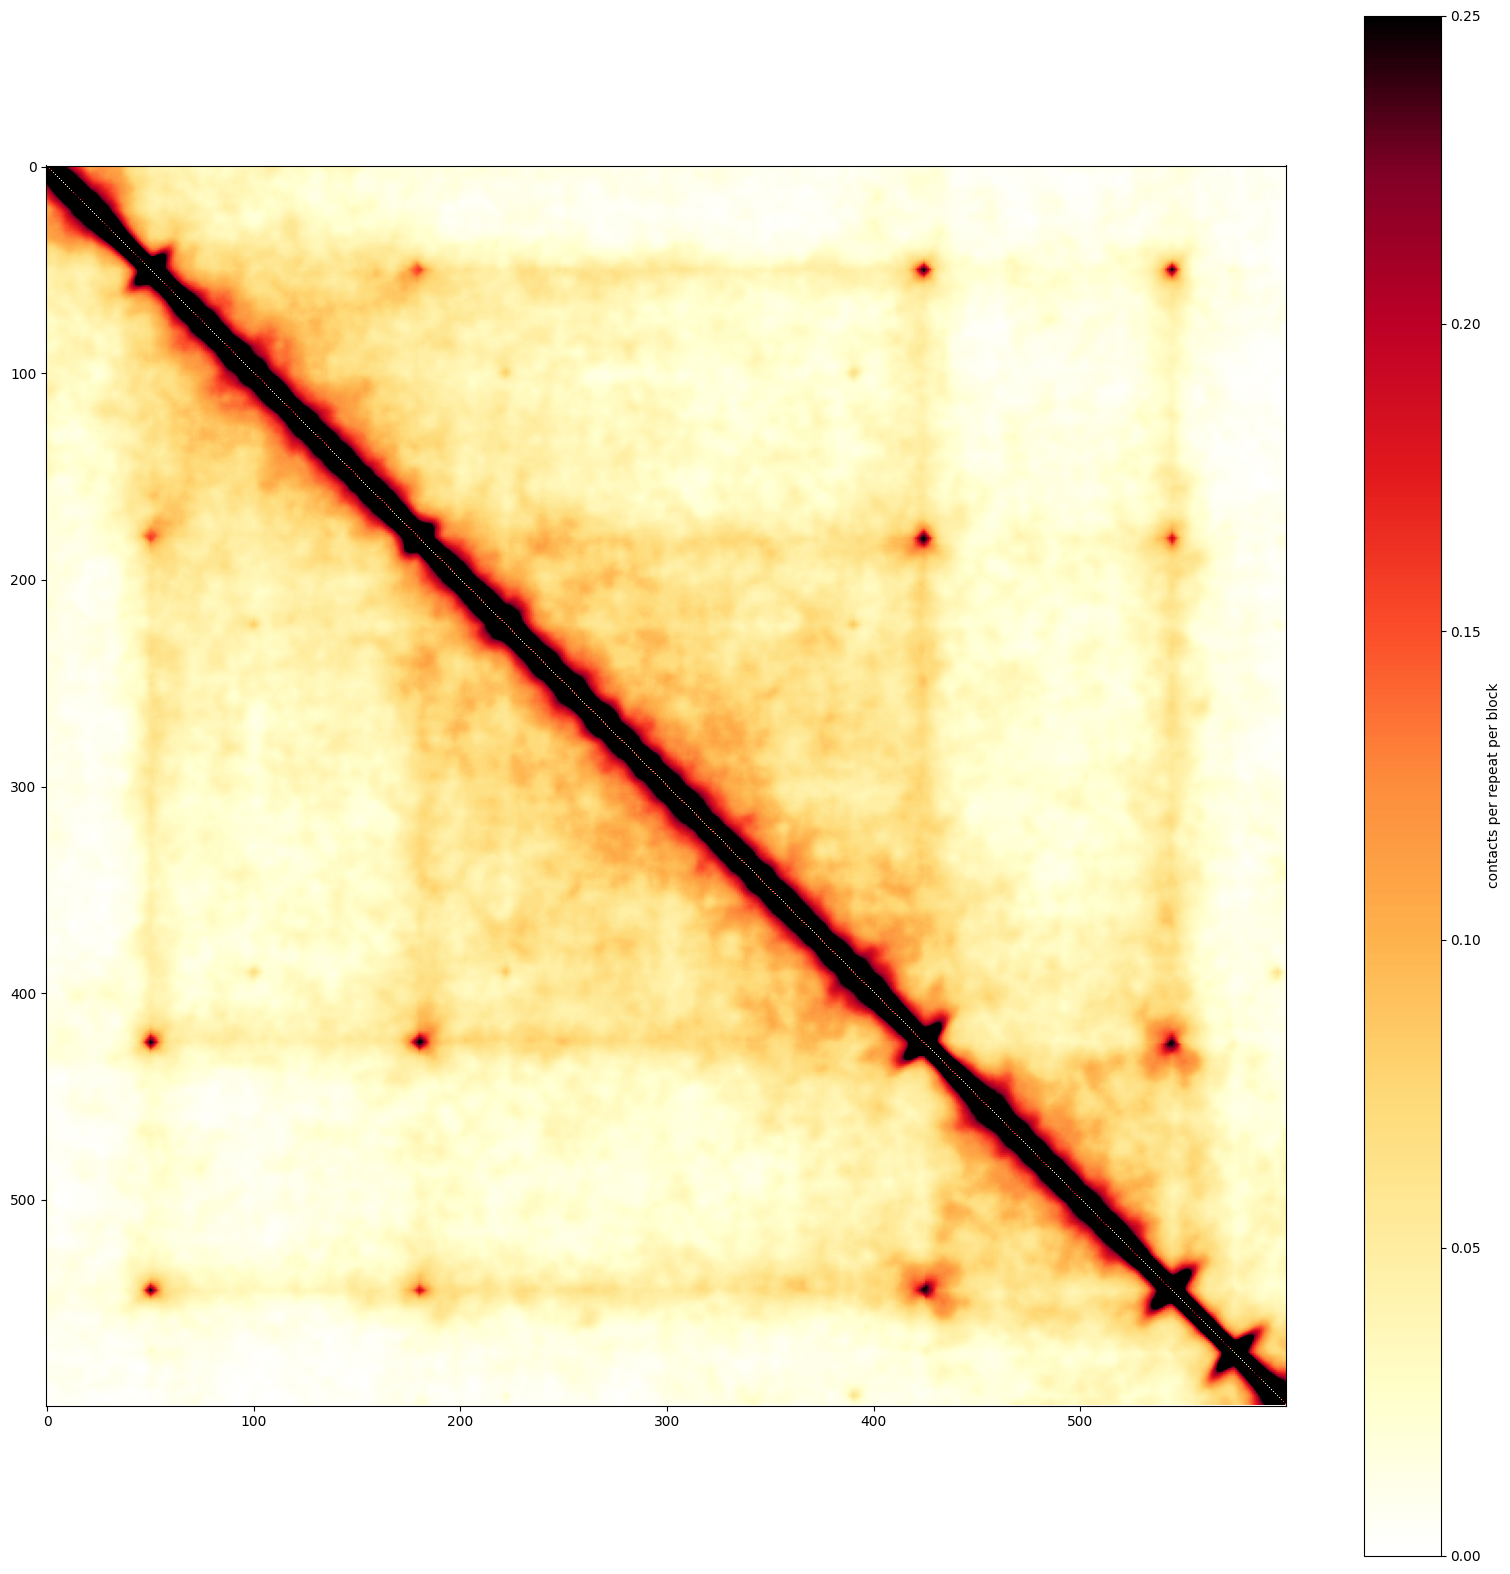

['sim_proc300_sep240_', 'n64_h0.4_llp2_w16_dens0.45']


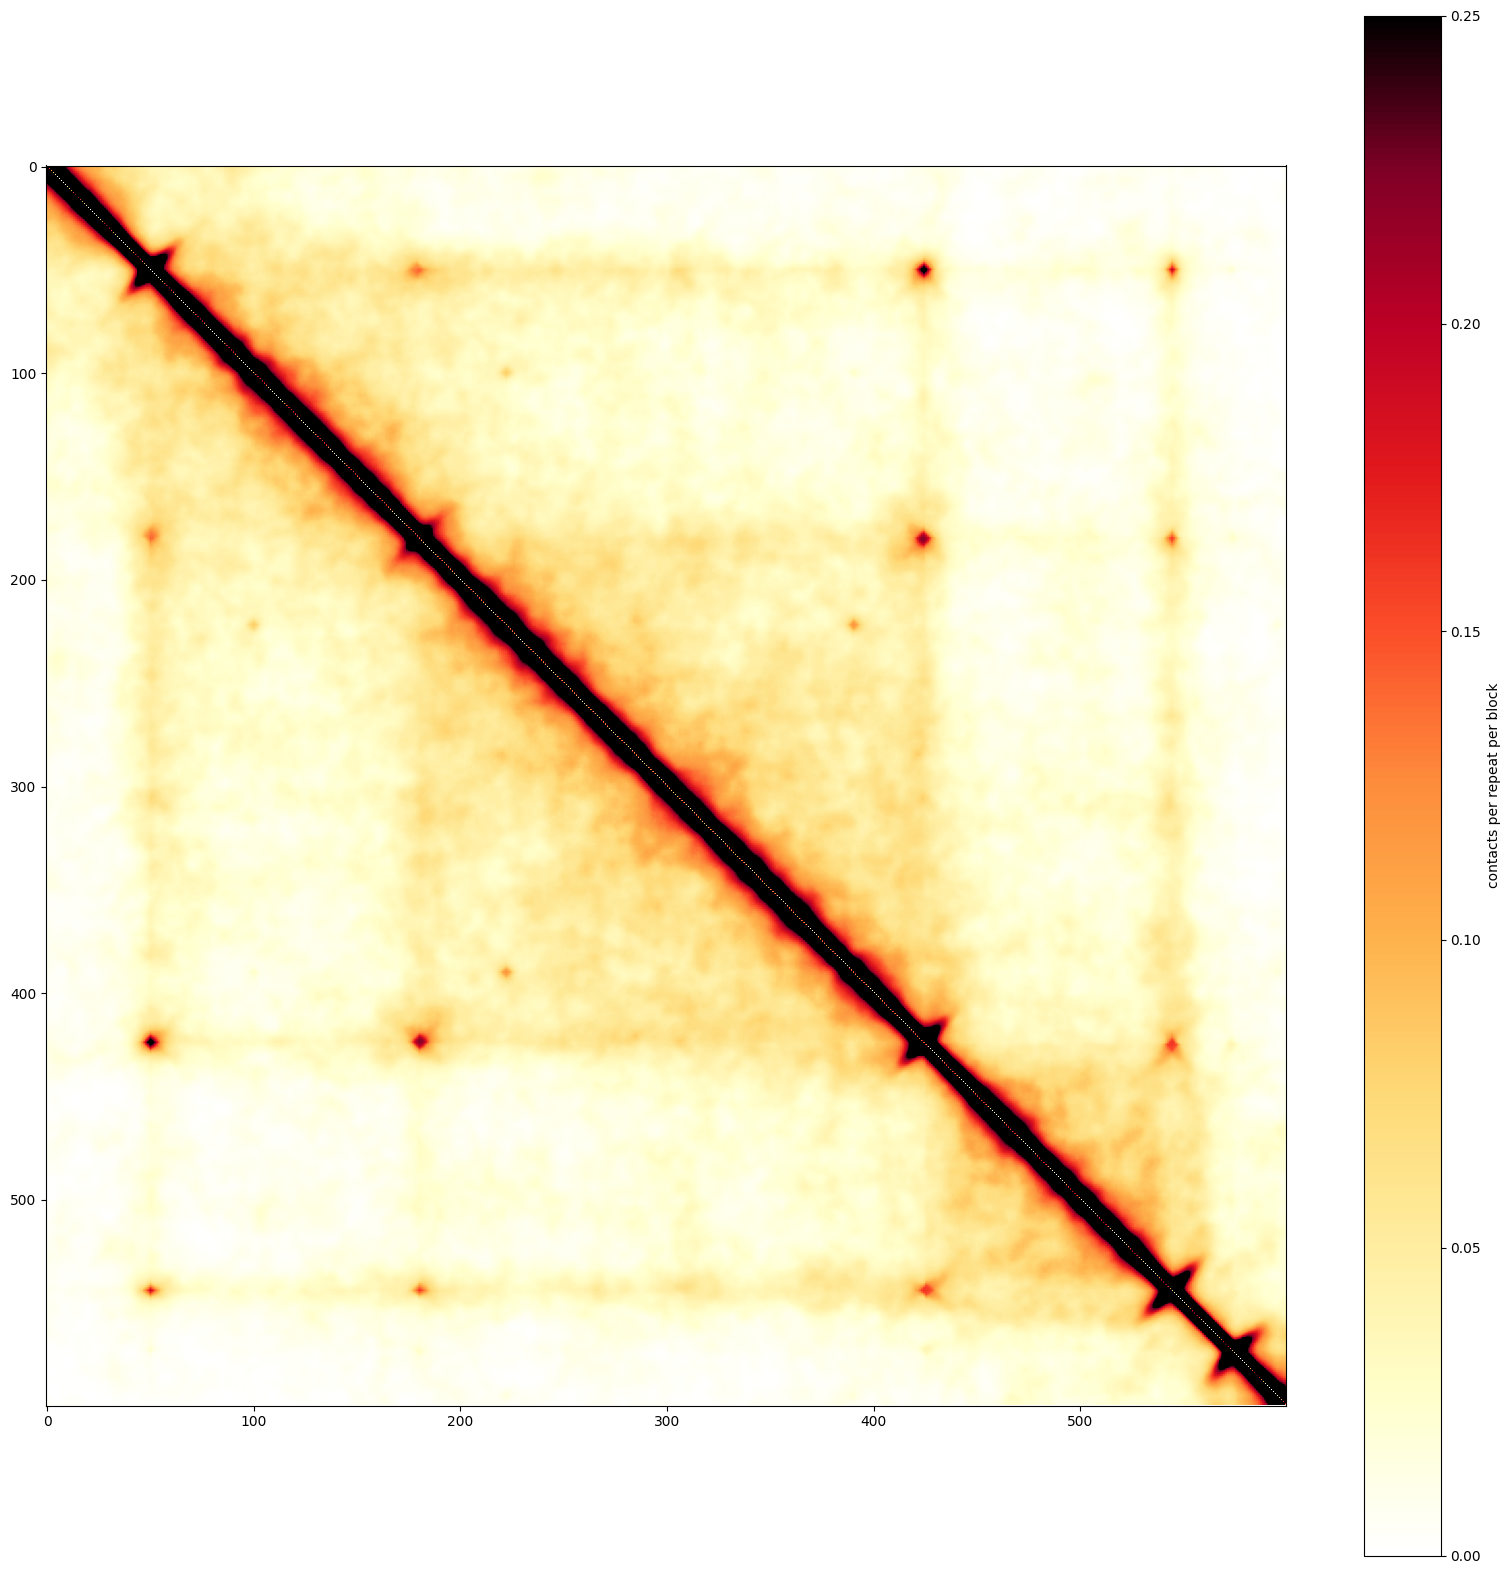

['sim_proc300_sep240_', 'n64_h0.4_llp2_w16_dens0.15']


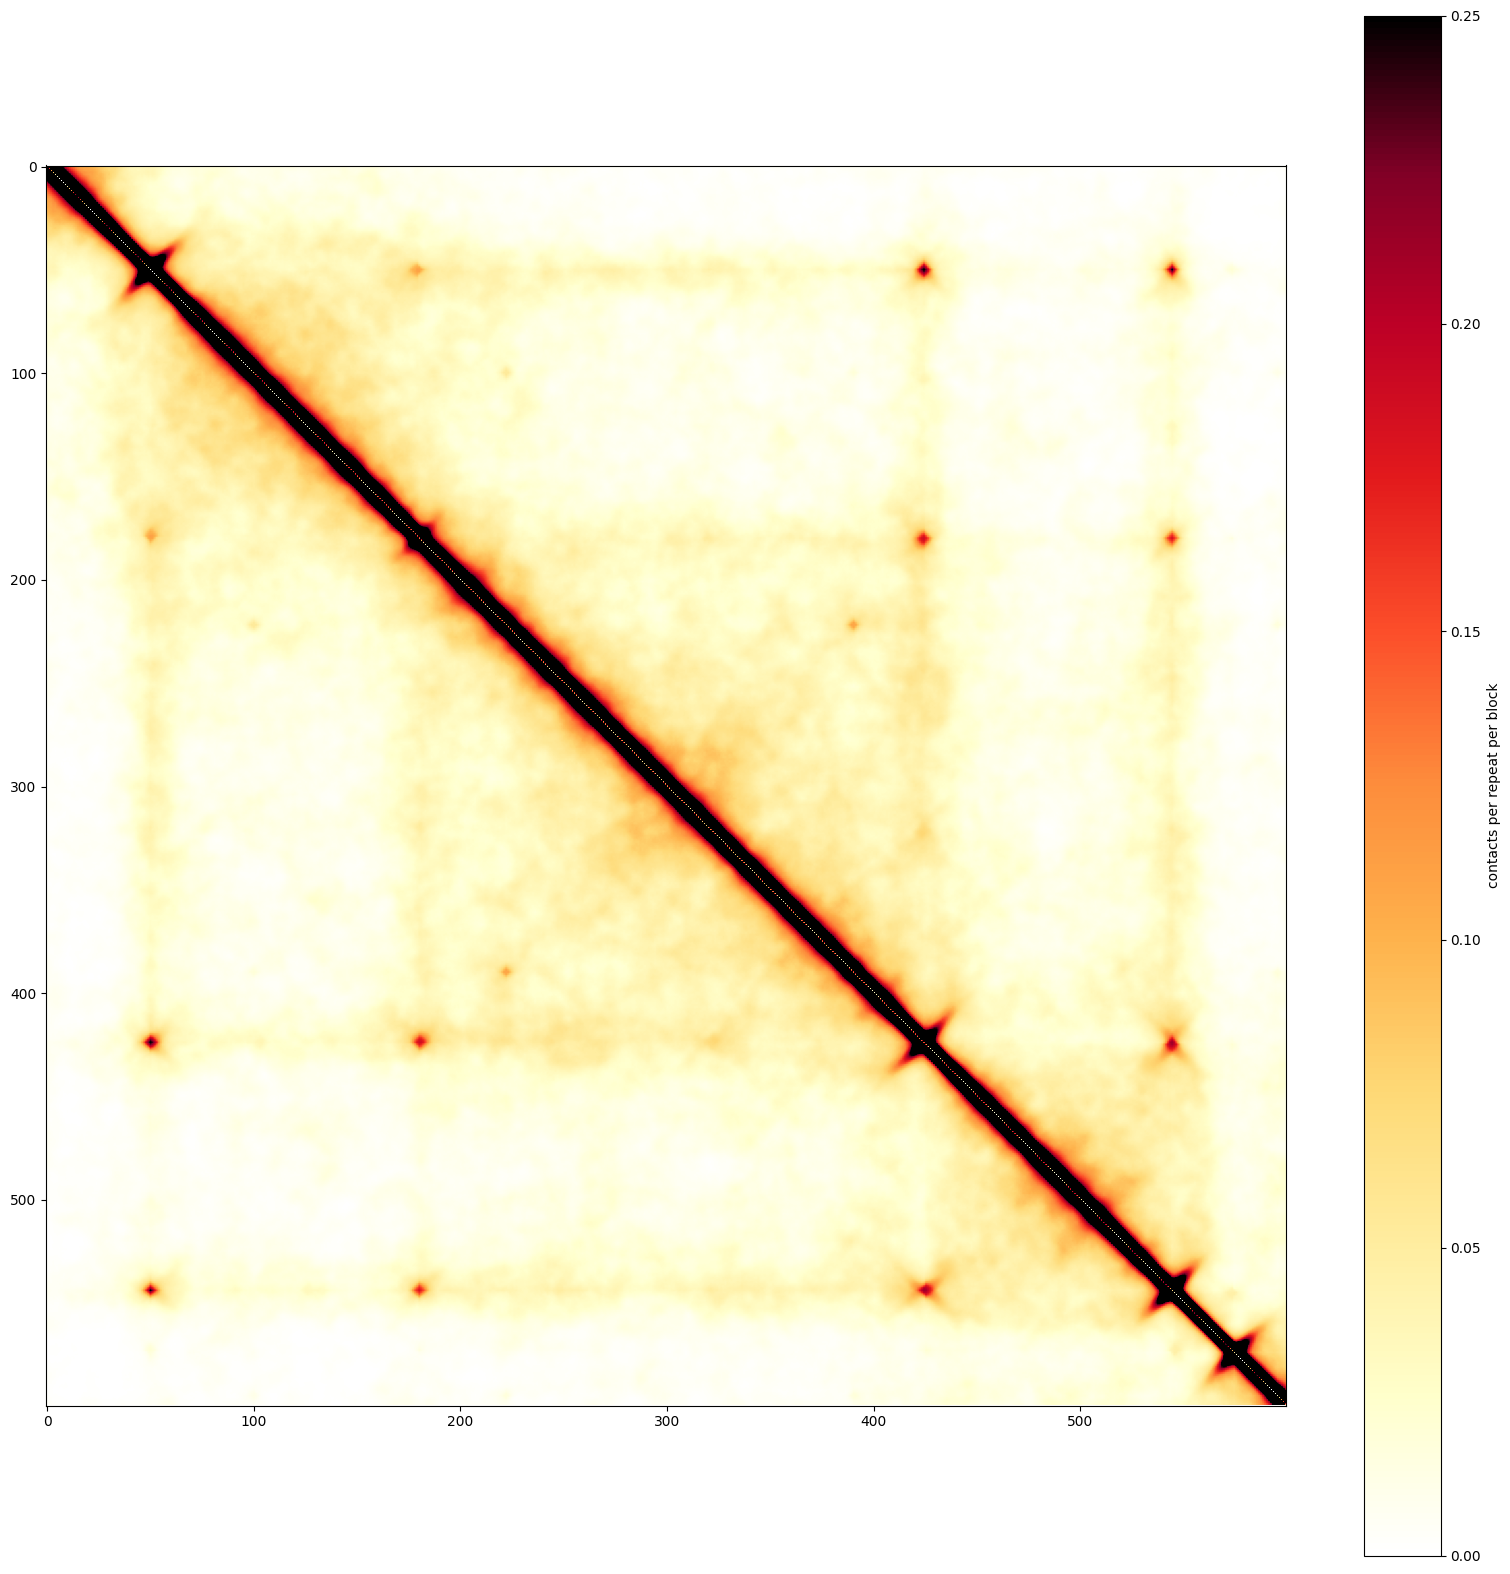

In [108]:
savedir = "/mnt/md1/varshini/Blood/sim_arrs/"
basedir = '/mnt/md1/varshini/Blood/sim_data_density/2026-04-16 14:53:25.739836/'

if not os.path.exists(savedir):
    os.mkdir(savedir)
    
region_size = 2000
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 0
block_end = 600
block_step = 1

cutoff = 3
nproc = 16

for f in os.listdir(basedir):
    if 'dens' in f:
        print(f.split('ctcf4_'))
        cm_rescaled = np.load(os.path.join(savedir, f"{f.split('ctcf4_')[1]}.npy"))
        # show rescaled contact map
        plt.figure(figsize=(20, 20))
        plt.imshow(cm_rescaled[150:750, 150:750], cmap='fall',vmax=0.25);
        plt.colorbar(label='contacts per repeat per block');
        plt.savefig(os.path.join(savedir, f"{f}.svg"))
        plt.show()